# Mosaic method comparison

Generate a README-ready image comparing `first`, `mean`, `median`, and `medoid` on the same Sentinel-2 AOI, date window, bands, masking, and scene order.

The notebook saves `../assets/mosaic-method-comparison.jpg`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from s2mosaic import mosaic

Use a compact Singapore AOI so the comparison remains quick while still sampling a persistently cloudy tropical setting. 
`cloud_mask="SCL"` avoids deep-learning inference and makes the example practical on CPU-only machines.

In [2]:
# Marina Bay / Singapore Strait: urban water edges plus frequent tropical cloud.
# UTM zone 48N (EPSG:32648) metres.
bounds = (365380, 135980, 378740, 147040)
bands = ["B04", "B03", "B02"]

methods = ["first", "mean", "median", "medoid"]

`median` is the public shortcut for `percentile=50`; the other methods do not need a `percentile` argument.

In [3]:
mosaics = {}
profile = None

for method in methods:
    array, profile = mosaic(
        bounds=bounds,
        input_crs=32648,
        snap_to_source_grid=True,
        start_year=2023,
        start_month=6,
        duration_months=2,
        bands=["B04", "B03", "B02"],
        mosaic_method=method,
        scene_order="valid_data",
        resolution=20,
        show_progress=True,
    )
    mosaics[method] = array
    print(f"{method:>6}: {array.shape}, {array.dtype}")

Phase 1: streaming bands for OCM cloud mask:   0%|          | 0/12 [00:00<?, ?scene/s]

Phase 2: aggregating tiles (first):   0%|          | 0/12 [00:00<?, ?read/s]

 first: (3, 553, 668), uint16


Phase 1: streaming bands for OCM cloud mask:   0%|          | 0/12 [00:00<?, ?scene/s]

Phase 2: aggregating tiles (mean):   0%|          | 0/27 [00:00<?, ?read/s]

...

Phase 2: aggregating tiles (percentile):   0%|          | 0/27 [00:00<?, ?read/s]

median: (3, 553, 668), uint16


Phase 1: streaming bands for OCM cloud mask:   0%|          | 0/12 [00:00<?, ?scene/s]

Phase 2: aggregating tiles (medoid):   0%|          | 0/27 [00:00<?, ?read/s]

medoid: (3, 553, 668), uint16


Apply one shared RGB stretch across all four mosaics. This keeps brightness and contrast comparable between panels.

In [4]:
def shared_rgb_limits(arrays, lower=2, upper=98):
    pixels = []
    for arr in arrays:
        rgb = arr[:3].astype(np.float32)
        valid = np.all(rgb > 0, axis=0)
        if valid.any():
            pixels.append(rgb[:, valid])
    if not pixels:
        return np.zeros(3, dtype=np.float32), np.ones(3, dtype=np.float32)
    samples = np.concatenate(pixels, axis=1)
    lo = np.percentile(samples, lower, axis=1).astype(np.float32)
    hi = np.percentile(samples, upper, axis=1).astype(np.float32)
    hi = np.maximum(hi, lo + 1)
    return lo, hi


def to_rgb(arr, lo, hi):
    rgb = arr[:3].astype(np.float32)
    rgb = (rgb - lo[:, None, None]) / (hi - lo)[:, None, None]
    rgb = np.clip(rgb, 0, 1)
    return np.moveaxis(rgb, 0, -1)


lo, hi = shared_rgb_limits(mosaics.values())

PosixPath('../assets/mosaic-method-comparison.jpg')

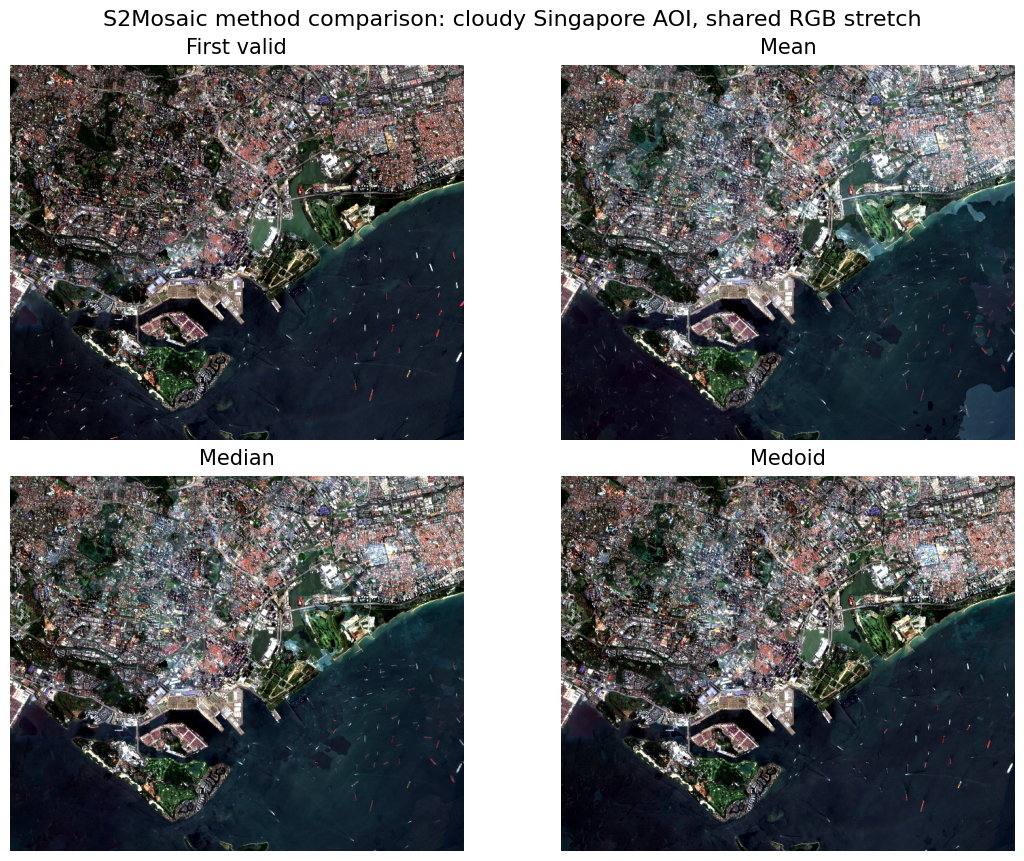

In [5]:
titles = {
    "first": "First valid",
    "mean": "Mean",
    "median": "Median",
    "medoid": "Medoid",
}

fig, axes = plt.subplots(2, 2, figsize=(11, 8.5), constrained_layout=True)
for ax, method in zip(axes.ravel(), methods, strict=True):
    ax.imshow(to_rgb(mosaics[method], lo, hi))
    ax.set_title(titles[method], fontsize=15, pad=8)
    ax.set_axis_off()

fig.suptitle(
    "S2Mosaic method comparison: cloudy Singapore AOI, shared RGB stretch",
    fontsize=16,
)

assets_dir = Path("..") / "assets"
assets_dir.mkdir(exist_ok=True)
out_path = assets_dir / "mosaic-method-comparison.jpg"
fig.savefig(out_path, dpi=160, bbox_inches="tight", pil_kwargs={"quality": 90})
out_path